# Koopman Operator Surrogate for Inverted Double Pendulum

SINDy with degree-2 polynomials plateaus at RMSE ≈ 1.05 because the pendulum's
nonlinear trig structure is poorly captured by truncated polynomials. The **Koopman
operator** offers a complementary approach: lift the state into a higher-dimensional
space where the dynamics become **linear**.

## EDMD-with-Control (EDMDc)

Given observable functions $g: \mathbb{R}^6 \to \mathbb{R}^d$, we fit matrices
$A \in \mathbb{R}^{d \times d}$, $B \in \mathbb{R}^{d \times 1}$ via least squares:

$$g(x_{k+1}) \approx A\, g(x_k) + B\, u_k$$

This is **Extended Dynamic Mode Decomposition with control**.

## Why trig observables beat polynomials for pendulums

The discrete-time angle update satisfies:

$$\sin(\theta_{k+1}) \approx \sin(\theta_k) + \Delta t \cdot \cos(\theta_k)\,\dot{\theta}_k$$

So the lifted observable $\psi_1 = \sin(\theta_1)$ evolves **linearly** in terms of
$\psi_2 = \cos(\theta_1) \cdot \dot{\theta}_1$ — a cross-term that degree-2 polynomials
cannot exactly represent (it requires $\cos\theta \cdot \dot\theta$, which after
Taylor-expanding $\cos\theta$ needs infinitely many polynomial terms).

## Experiment plan
1. Fit EDMDc with three observable sets: poly-2, poly-3, trig-poly
2. Compare one-step RMSE against SINDy baseline
3. Assess multi-step rollout quality
4. Train PPO in the best Koopman surrogate
5. Evaluate policy in real MuJoCo simulator

In [53]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import warnings

from gymnasium import spaces
from sklearn.preprocessing import PolynomialFeatures
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

warnings.filterwarnings("ignore", category=UserWarning)

CWD = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [CWD, *CWD.parents] if (p / "pyproject.toml").exists())
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "results" / "koopman"
MODEL_DIR.mkdir(exist_ok=True, parents=True)

_env = gym.make("InvertedDoublePendulum-v5")
DT = _env.unwrapped.dt
_env.close()

STATE_DIM  = 6
ACTION_DIM = 1
L1, L2     = 0.6, 0.6
TIP_HEIGHT_FALL_THRESHOLD = 1.0
TIP_HEIGHT_TARGET         = 2.0
HEALTHY_REWARD            = 10.0
STATE_HIGH = np.array([5.0, np.pi, np.pi, 20.0, 20.0, 20.0])

# SINDy deg-2 baseline from trackA_sindy_dynamics.ipynb (iter-0, 50k transitions)
SINDY_RMSE_BASELINE = 1.053028

print(f"DT = {DT:.4f} s  ({1/DT:.0f} Hz)")
print(f"Project root: {PROJECT_ROOT}")

DT = 0.0500 s  (20 Hz)
Project root: /Users/patrick/Documents/personal/UW/ME_595


## 1. Shared Utilities

In [54]:
def obs_to_state6(obs):
    """9-dim MuJoCo observation → 6-dim state [x, θ₁, θ₂, ẋ, θ̇₁, θ̇₂]."""
    return np.array([
        obs[0],
        np.arctan2(obs[1], obs[3]),
        np.arctan2(obs[2], obs[4]),
        obs[5], obs[6], obs[7],
    ])


def tip_position(s):
    x, th1, th2 = s[0], s[1], s[2]
    x_tip  = x + L1*np.sin(th1) + L2*np.sin(th1 + th2)
    tip_h  = L1*np.cos(th1) + L2*np.cos(th1 + th2)
    return float(x_tip), float(tip_h)


def rollout_mujoco(x0, U_seq, seed=0):
    """Ground-truth rollout in MuJoCo from initial state x0."""
    env = gym.make("InvertedDoublePendulum-v5")
    env.reset(seed=seed)
    env.unwrapped.set_state(x0[:3], x0[3:])
    traj = [x0.copy()]
    for u in U_seq:
        obs, _, term, trunc, _ = env.step(np.array(u, dtype=np.float32).reshape(1))
        traj.append(obs_to_state6(obs))
        if term or trunc:
            break
    env.close()
    return np.array(traj)

## 2. Load Bootstrap Data

Reuse the 50k near-upright transitions already collected by `trackA_sindy_dynamics.ipynb`.
This ensures a direct apples-to-apples comparison with the SINDy RMSE baseline.

In [55]:
d = np.load(DATA_DIR / "trajectories_trackA_probe_bootstrap.npz")
X_all, U_all, Xn_all = d["X"], d["U"], d["X_next"]

rng     = np.random.default_rng(42)
n       = len(X_all)
idx     = rng.permutation(n)
n_test  = max(1, n // 5)
idx_te  = idx[:n_test]
idx_tr  = idx[n_test:]

X_tr,  U_tr,  Xn_tr  = X_all[idx_tr], U_all[idx_tr], Xn_all[idx_tr]
X_te,  U_te,  Xn_te  = X_all[idx_te], U_all[idx_te], Xn_all[idx_te]

print(f"Total transitions : {n:,}")
print(f"Train / test      : {len(X_tr):,} / {len(X_te):,}")
print(f"State range (train):")
labels = ["x", "θ₁", "θ₂", "ẋ", "θ̇₁", "θ̇₂"]
for i, lab in enumerate(labels):
    print(f"  {lab:4s}: [{X_tr[:, i].min():.2f}, {X_tr[:, i].max():.2f}]")

Total transitions : 50,000
Train / test      : 40,000 / 10,000
State range (train):
  x   : [-1.50, 1.50]
  θ₁  : [-0.84, 0.84]
  θ₂  : [-1.15, 1.14]
  ẋ   : [-5.00, 5.64]
  θ̇₁ : [-9.38, 8.58]
  θ̇₂ : [-8.73, 9.55]


## 3. Observable / Lifting Functions

Three candidates:

| Name | Description | Why |
|------|-------------|-----|
| **poly-2** | Degree-2 polynomial (same as SINDy) | Baseline — is EDMD at all better than SINDy with the same features? |
| **poly-3** | Degree-3 polynomial | More expressive without prior physical knowledge |
| **trig-poly** | Identity + trig + velocity×trig cross-terms | Encodes exact pendulum kinematics |

In [56]:
class _CachedPoly:
    """Fit PolynomialFeatures once on first call; reuse transformer thereafter."""
    def __init__(self, degree):
        self._pf  = PolynomialFeatures(degree=degree, include_bias=False)
        self._fit = False

    def __call__(self, X):
        if not self._fit:
            self._pf.fit(X)
            self._fit = True
        return self._pf.transform(X)


def lift_trig_poly(X):
    """
    Trig-enhanced Koopman observables for double pendulum.

    Key design choice: pair each trig observable with its natural derivative
    companion so the Koopman linear map can represent the update exactly:

        sin(θ_{k+1}) ≈ sin(θ_k) + dt · cos(θ_k)·ω_k
        cos(θ_{k+1}) ≈ cos(θ_k) − dt · sin(θ_k)·ω_k

    so the pair (sin θ, cos θ·ω) is closed under one-step evolution.
    """
    x, th1, th2, xd, om1, om2 = X.T
    th12 = th1 + th2

    s1,  c1  = np.sin(th1),  np.cos(th1)
    s2,  c2  = np.sin(th2),  np.cos(th2)
    s12, c12 = np.sin(th12), np.cos(th12)

    return np.column_stack([
        # ── identity (required for state reconstruction) ─────────────────
        x, th1, th2, xd, om1, om2,

        # ── primary trig per hinge and combined ─────────────────────────
        s1, c1,
        s2, c2,
        s12, c12,

        # ── derivative companions: d(sin θ)/dt = cos θ · ω ──────────────
        c1*om1,  s1*om1,           # for sin θ₁, cos θ₁
        c2*om2,  s2*om2,           # for sin θ₂, cos θ₂
        c12*(om1+om2), s12*(om1+om2),  # for sin(θ₁+θ₂)

        # ── kinetic / centripetal terms ──────────────────────────────────
        xd**2, om1**2, om2**2,
        om1*om2, xd*om1, xd*om2,

        # ── cart-pole coupling ───────────────────────────────────────────
        x*s1, x*c1, xd*c1, xd*c2,

        # ── double-angle terms (energy-like) ────────────────────────────
        np.sin(2*th1), np.cos(2*th1),
        np.sin(2*th2), np.cos(2*th2),

        # ── cross-hinge coupling ─────────────────────────────────────────
        c1*om2, s1*om2,
        c2*om1, s2*om1,
    ])


LIFTERS = {
    "poly-2":    _CachedPoly(degree=2),
    "poly-3":    _CachedPoly(degree=3),
    "trig-poly": lift_trig_poly,
}

# Print lifted dimensions
for name, fn in LIFTERS.items():
    d_z = fn(X_tr[:5]).shape[1]
    print(f"  {name:>10}  d_z = {d_z}")

      poly-2  d_z = 27
      poly-3  d_z = 83
   trig-poly  d_z = 36


## 4. EDMD Fitting

Solve the least-squares problem on the lifted transitions:

$$[A \mid B] = G'^\top \, [G^\top \mid U^\top]^+$$

where $G = [g(x_1), \dots, g(x_N)]^\top \in \mathbb{R}^{N \times d}$.

In [57]:
def fit_edmd(X_tr, U_tr, Xn_tr, lift_fn, rcond=None):
    """
    Fit EDMDc: g(x_{k+1}) = A·g(x_k) + B·u_k

    Returns (A, B, train_rmse). RMSE is computed only on the first STATE_DIM
    lifted components (the identity block), so it is directly comparable to
    the SINDy one-step RMSE which predicts x_{k+1} directly.
    """
    Z    = lift_fn(X_tr)   # N × d_z
    Zn   = lift_fn(Xn_tr)  # N × d_z
    d_z  = Z.shape[1]

    Omega         = np.hstack([Z, U_tr])         # N × (d_z + 1)
    AB_T, _, _, _ = np.linalg.lstsq(Omega, Zn, rcond=rcond)
    A = AB_T[:d_z, :].T   # d_z × d_z
    B = AB_T[d_z:,  :].T  # d_z × 1

    Zn_hat  = Z @ A.T + U_tr @ B.T
    rmse_tr = float(np.sqrt(np.mean((Zn_hat[:, :STATE_DIM] - Zn[:, :STATE_DIM])**2)))
    return A, B, rmse_tr


def eval_edmd(A, B, X_te, U_te, Xn_te, lift_fn):
    """One-step test RMSE in original state space."""
    Z    = lift_fn(X_te)
    Zn   = lift_fn(Xn_te)
    Zn_h = Z @ A.T + U_te @ B.T
    return float(np.sqrt(np.mean((Zn_h[:, :STATE_DIM] - Zn[:, :STATE_DIM])**2)))

## 5. Fit and Compare Observable Sets

In [58]:
results = {}

for name, lift_fn in LIFTERS.items():
    d_z = lift_fn(X_tr[:5]).shape[1]
    print(f"Fitting EDMD  {name:>10}  (d_z = {d_z}) ...", end="  ", flush=True)
    A, B, rmse_tr = fit_edmd(X_tr, U_tr, Xn_tr, lift_fn)
    rmse_te       = eval_edmd(A, B, X_te, U_te, Xn_te, lift_fn)
    results[name] = {"A": A, "B": B, "lift_fn": lift_fn,
                     "d_z": d_z, "rmse_tr": rmse_tr, "rmse_te": rmse_te}
    print(f"train RMSE {rmse_tr:.6f}  |  test RMSE {rmse_te:.6f}")

print()
print(f"{'Model':>15}  {'d_z':>5}  {'Train RMSE':>12}  {'Test RMSE':>12}  {'vs SINDy':>10}")
print("-" * 62)
print(f"{'SINDy deg-2':>15}  {'  36':>5}  {'—':>12}  {SINDY_RMSE_BASELINE:>12.6f}  {'(baseline)':>10}")
for name, r in results.items():
    delta = r["rmse_te"] - SINDY_RMSE_BASELINE
    sign  = "+" if delta >= 0 else ""
    print(f"  {name:>13}  {r['d_z']:>5}  {r['rmse_tr']:>12.6f}  {r['rmse_te']:>12.6f}  {sign}{delta:>+9.4f}")

Fitting EDMD      poly-2  (d_z = 27) ...  train RMSE 1.059849  |  test RMSE 1.075969
Fitting EDMD      poly-3  (d_z = 83) ...  train RMSE 0.624572  |  test RMSE 0.644444
Fitting EDMD   trig-poly  (d_z = 36) ...  train RMSE 0.975005  |  test RMSE 0.997179

          Model    d_z    Train RMSE     Test RMSE    vs SINDy
--------------------------------------------------------------
    SINDy deg-2     36             —      1.053028  (baseline)
         poly-2     27      1.059849      1.075969  +  +0.0229
         poly-3     83      0.624572      0.644444    -0.4086
      trig-poly     36      0.975005      0.997179    -0.0558


## 6. RMSE Comparison Plot

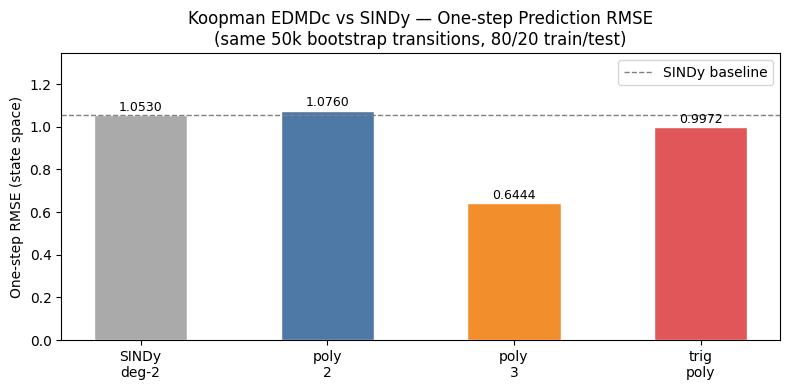

In [59]:
names_plot  = ["SINDy\ndeg-2"] + [n.replace("-", "\n") for n in results]
rmses_plot  = [SINDY_RMSE_BASELINE] + [r["rmse_te"] for r in results.values()]
colors_plot = ["#aaaaaa", "#4e79a7", "#f28e2b", "#e15759"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names_plot, rmses_plot, color=colors_plot, edgecolor="white", width=0.5)
ax.axhline(SINDY_RMSE_BASELINE, color="gray", ls="--", lw=1, label="SINDy baseline")
for bar, rmse in zip(bars, rmses_plot):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{rmse:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("One-step RMSE (state space)")
ax.set_title("Koopman EDMDc vs SINDy — One-step Prediction RMSE\n(same 50k bootstrap transitions, 80/20 train/test)")
ax.set_ylim(0, max(rmses_plot) * 1.25)
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / "koopman_rmse_comparison.png", dpi=150)
plt.show()

## 7. Multi-step Rollout Quality

RMSE measures one-step accuracy. For RL surrogates we care about rollout fidelity over
tens to hundreds of steps. Here we compare:
- **MuJoCo ground truth** (black)
- **Best Koopman model** with project-and-re-lift strategy

**Project-and-re-lift** at each step:
1. $z_k = g(x_k)$ — lift current state  
2. $z_{k+1} = A z_k + B u_k$ — Koopman step  
3. $x_{k+1} = z_{k+1}[:6]$ — decode  
4. Repeat from 1

This constrains the trajectory to stay in the image of $g$, avoiding unbounded drift.

Best model: poly-3  (test RMSE = 0.644444)


/Users/patrick/Documents/personal/UW/ME_595/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_polynomial.py:547: RuntimeWarning: overflow encountered in multiply
  np.multiply(
/Users/patrick/Documents/personal/UW/ME_595/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_polynomial.py:547: RuntimeWarning: overflow encountered in multiply
  np.multiply(
/Users/patrick/Documents/personal/UW/ME_595/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_polynomial.py:547: RuntimeWarning: overflow encountered in multiply
  np.multiply(
/Users/patrick/Documents/personal/UW/ME_595/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_polynomial.py:547: RuntimeWarning: overflow encountered in multiply
  np.multiply(


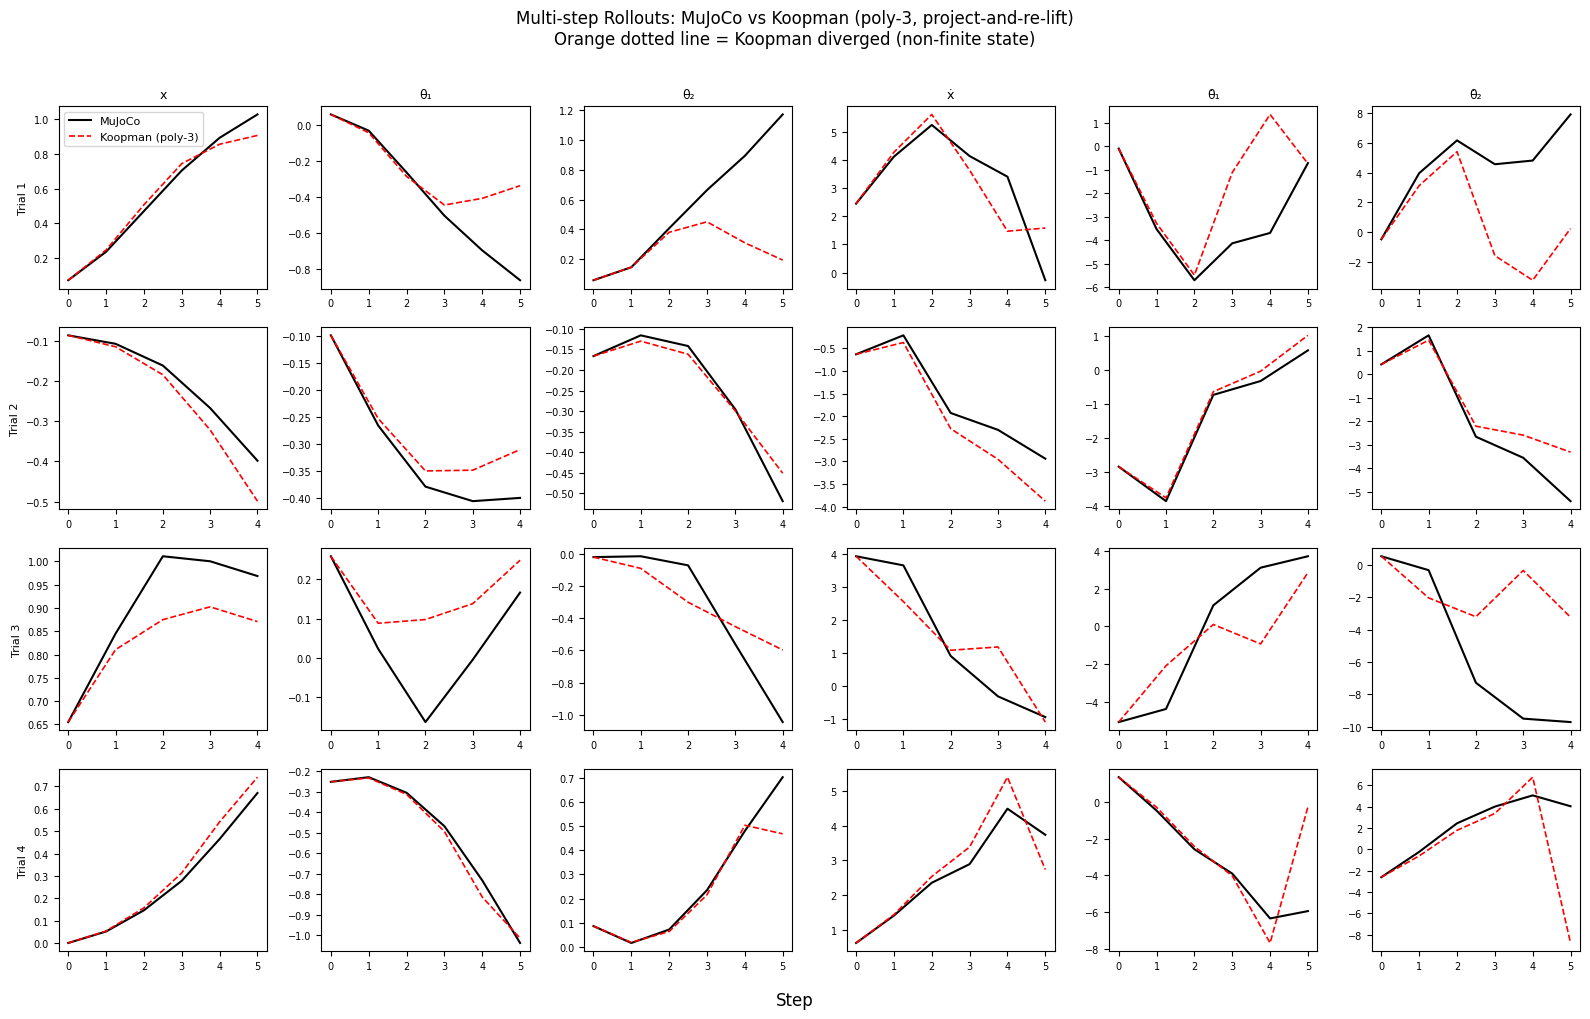

Mean rollout RMSE (50 steps, 4 trials): 1.9160


In [60]:
def rollout_koopman(A, B, lift_fn, x0, U_seq):
    """Project-and-re-lift rollout: lift → Koopman step → decode → repeat.

    Stops early if the decoded state goes non-finite. Koopman matrices with
    spectral radius > 1 will diverge to NaN/inf; lifting a NaN state crashes
    sklearn's PolynomialFeatures, so we guard before each lift.
    """
    x    = x0.copy()
    traj = [x.copy()]
    for u in U_seq:
        if not np.all(np.isfinite(x)):
            break
        z     = lift_fn(x.reshape(1, -1))                    # 1 × d_z
        z_nxt = z @ A.T + np.array([[u]]) @ B.T              # 1 × d_z
        x     = z_nxt[0, :STATE_DIM]                         # decode
        traj.append(x.copy())
    return np.array(traj)


# Pick the model with lowest test RMSE
best_name = min(results, key=lambda k: results[k]["rmse_te"])
best      = results[best_name]
print(f"Best model: {best_name}  (test RMSE = {best['rmse_te']:.6f})")

N_ROLLOUT_STEPS = 50
N_TRIALS        = 4
rng_r           = np.random.default_rng(7)

state_labels = ["x", "θ₁", "θ₂", "ẋ", "θ̇₁", "θ̇₂"]
fig, axes = plt.subplots(N_TRIALS, STATE_DIM, figsize=(16, 2.5 * N_TRIALS), sharex=False)

rmse_rollout    = []
diverged_trials = []

for trial in range(N_TRIALS):
    idx_ic = rng_r.integers(0, len(X_tr))
    x0     = X_tr[idx_ic].copy()
    U_seq  = rng_r.uniform(-1.0, 1.0, size=N_ROLLOUT_STEPS)

    traj_mj = rollout_mujoco(x0, U_seq)
    traj_kp = rollout_koopman(best["A"], best["B"], best["lift_fn"], x0, U_seq)

    diverged = len(traj_kp) < len(traj_mj) + 1  # Koopman went non-finite
    if diverged:
        diverged_trials.append(trial + 1)

    n_steps = min(len(traj_mj), len(traj_kp))
    traj_mj_clip = traj_mj[:n_steps]
    traj_kp_clip = traj_kp[:n_steps]
    rmse_rollout.append(np.sqrt(np.mean((traj_mj_clip - traj_kp_clip)**2)))

    t = np.arange(n_steps)
    for col, lab in enumerate(state_labels):
        ax = axes[trial, col]
        ax.plot(t, traj_mj_clip[:, col], "k-",  lw=1.5,
                label="MuJoCo" if trial == 0 and col == 0 else "_")
        ax.plot(t, traj_kp_clip[:, col], "r--", lw=1.2,
                label=f"Koopman ({best_name})" if trial == 0 and col == 0 else "_")
        if trial == 0:
            ax.set_title(lab, fontsize=9)
        if diverged:
            ax.axvline(n_steps - 1, color="orange", lw=1, ls=":", alpha=0.7)
        ax.tick_params(labelsize=7)

    axes[trial, 0].set_ylabel(f"Trial {trial+1}" + (" ⚠div" if diverged else ""), fontsize=8)

axes[0, 0].legend(fontsize=8)
fig.supxlabel("Step", y=0.01)
fig.suptitle(f"Multi-step Rollouts: MuJoCo vs Koopman ({best_name}, project-and-re-lift)\n"
             f"Orange dotted line = Koopman diverged (non-finite state)", y=1.01)
plt.tight_layout()
plt.savefig(MODEL_DIR / "koopman_rollout_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean rollout RMSE ({N_ROLLOUT_STEPS} steps, {N_TRIALS} trials): {np.mean(rmse_rollout):.4f}")
if diverged_trials:
    print(f"Koopman diverged (non-finite) in trials: {diverged_trials}")
    print("  → spectral radius of A > 1; rollout is only valid for first ~N stable steps")

## 8. Koopman Surrogate Gymnasium Environment

Mirrors `SINDySurrogateEnv` but uses the Koopman linear step in the lifted space.
State seen by the policy is always the 6D decoded state from the first components of $z$.

In [61]:
class KoopmanSurrogateEnv(gym.Env):
    """
    Gymnasium env backed by an EDMDc Koopman model.

    One environment step:
      1. z_k = g(x_k)              lift to observable space
      2. z_{k+1} = A z_k + B u_k  Koopman linear step
      3. x_{k+1} = z_{k+1}[:6]    decode state

    Reward / termination mirrors InvertedDoublePendulum-v5.
    Non-finite states (Koopman divergence) immediately terminate with reward 0.
    """
    metadata = {"render_modes": []}

    def __init__(self, A, B, lift_fn, initial_states, max_steps=1000):
        super().__init__()
        self.A              = A
        self.B              = B
        self.lift_fn        = lift_fn
        self.initial_states = np.asarray(initial_states)
        self.max_steps      = max_steps
        self.observation_space = spaces.Box(
            low=-STATE_HIGH, high=STATE_HIGH, shape=(STATE_DIM,), dtype=np.float64
        )
        self.action_space = spaces.Box(-1.0, 1.0, shape=(1,), dtype=np.float32)
        self._s = None
        self._n = 0

    def _tip_position(self):
        return tip_position(self._s)

    def _terminated(self):
        if not np.all(np.isfinite(self._s)):
            return True
        if np.any(np.abs(self._s) > STATE_HIGH):
            return True
        _, tip_h = self._tip_position()
        return bool(tip_h <= TIP_HEIGHT_FALL_THRESHOLD)

    def _reward(self, terminated):
        # Non-finite state means Koopman diverged; return 0 to avoid NaN in SB3 advantages
        if not np.all(np.isfinite(self._s)):
            return 0.0
        x_tip, tip_h = self._tip_position()
        dist_pen = 0.01*x_tip**2 + (tip_h - TIP_HEIGHT_TARGET)**2
        vel_pen  = 1e-3*np.clip(self._s[4], -10, 10)**2 + 5e-3*np.clip(self._s[5], -10, 10)**2
        return float(HEALTHY_REWARD * int(not terminated) - dist_pen - vel_pen)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        idx     = self.np_random.integers(0, len(self.initial_states))
        self._s = self.initial_states[idx].copy()
        self._s += self.np_random.normal(0.0, 0.01, STATE_DIM)
        self._n = 0
        return self._s.copy(), {}

    def step(self, action):
        u = np.clip(np.asarray(action, dtype=np.float64).reshape(1, 1), -1.0, 1.0)
        z          = self.lift_fn(self._s.reshape(1, -1))   # 1 × d_z
        z_next     = z @ self.A.T + u @ self.B.T            # 1 × d_z
        self._s    = z_next[0, :STATE_DIM]
        terminated = self._terminated()
        reward     = self._reward(terminated)
        self._n   += 1
        truncated  = self._n >= self.max_steps
        # Clip returned obs to stay within declared bounds (avoids SB3 obs-space warnings)
        obs = np.clip(self._s, -STATE_HIGH, STATE_HIGH)
        return obs, reward, terminated, truncated, {}

    def render(self):
        pass


# Smoke test
from gymnasium.utils.env_checker import check_env
_test = KoopmanSurrogateEnv(best["A"], best["B"], best["lift_fn"], X_tr[:200])
check_env(_test)
obs, _ = _test.reset(seed=0)
for _ in range(10):
    obs, r, term, trunc, _ = _test.step(_test.action_space.sample())
print(f"env_checker: OK  |  10 random steps done, final reward: {r:.4f}")

env_checker: OK  |  10 random steps done, final reward: -4.6370


## 9. Train PPO in Koopman Surrogate

Same PPO hyperparameters as the SINDy Track A notebook for a fair comparison.

In [62]:
KOOPMAN_PPO_STEPS = 50_000

print(f"Training PPO in Koopman ({best_name}) surrogate for {KOOPMAN_PPO_STEPS:,} steps...")
surr_env = Monitor(KoopmanSurrogateEnv(
    best["A"], best["B"], best["lift_fn"], X_tr, max_steps=1000
))
koopman_ppo = PPO(
    "MlpPolicy", surr_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    ent_coef=0.01,
    verbose=0,
)
koopman_ppo.learn(total_timesteps=KOOPMAN_PPO_STEPS, progress_bar=True)
koopman_ppo.save(str(MODEL_DIR / "ppo_koopman"))

recent_rewards = surr_env.get_episode_rewards()[-100:]
recent_lengths = surr_env.get_episode_lengths()[-100:]
print(f"Final-100-ep surrogate mean reward : {np.mean(recent_rewards):.2f}")
print(f"Final-100-ep surrogate mean length : {np.mean(recent_lengths):.0f} steps")

Output()

Training PPO in Koopman (poly-3) surrogate for 50,000 steps...


Final-100-ep surrogate mean reward : 234.26
Final-100-ep surrogate mean length : 27 steps


## 10. Evaluate Policy in Real MuJoCo Simulator

── Koopman EDMDc PPO — real MuJoCo evaluation ──────────────────────────
  Surrogate model         : poly-3  (d_z = 83)
  One-step RMSE           : 0.644444  (SINDy: 1.053028)
  mean_return             : 75.29 ± 19.35
  mean_len                : 9.3  steps
  success ≥ 500 steps       : 0%
  complete (≥ 999 steps)  : 0%



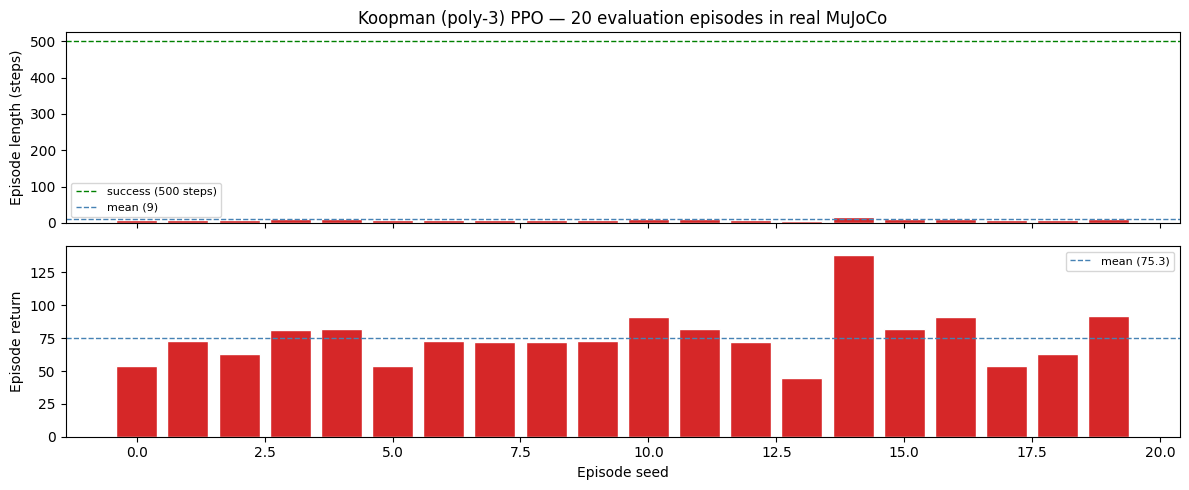

Rendering best episode (seed=14, length=16 steps)...


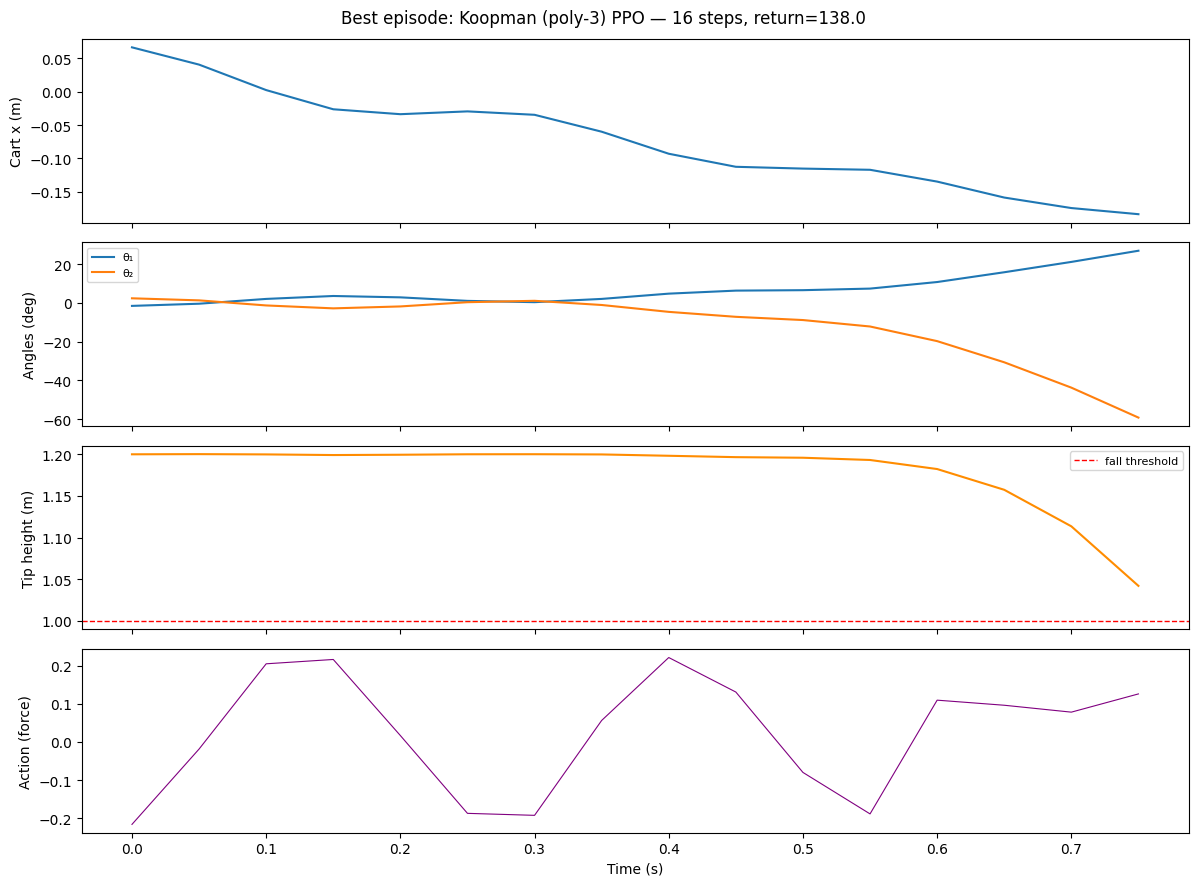

In [63]:
N_EVAL           = 20
CONV_SUCCESS_STEPS = 500   # mirrors sindy-rl.ipynb definition

eval_env = gym.make("InvertedDoublePendulum-v5")
ep_rewards, ep_lengths = [], []

for seed in range(N_EVAL):
    obs, _ = eval_env.reset(seed=seed)
    done = False
    ep_r = ep_l = 0
    while not done:
        state  = obs_to_state6(obs)
        action, _ = koopman_ppo.predict(state, deterministic=True)
        obs, r, term, trunc, _ = eval_env.step(action)
        done  = term or trunc
        ep_r += r
        ep_l += 1
    ep_rewards.append(ep_r)
    ep_lengths.append(ep_l)

eval_env.close()

lengths = np.array(ep_lengths)
returns = np.array(ep_rewards)

# ── Summary table (mirrors sindy-rl.ipynb summarize_episodes) ─────────────────
print("── Koopman EDMDc PPO — real MuJoCo evaluation ──────────────────────────")
print(f"  Surrogate model         : {best_name}  (d_z = {best['d_z']})")
print(f"  One-step RMSE           : {best['rmse_te']:.6f}  (SINDy: {SINDY_RMSE_BASELINE:.6f})")
print(f"  mean_return             : {returns.mean():.2f} ± {returns.std():.2f}")
print(f"  mean_len                : {lengths.mean():.1f}  steps")
print(f"  success ≥ {CONV_SUCCESS_STEPS} steps       : {np.mean(lengths >= CONV_SUCCESS_STEPS):.0%}")
print(f"  complete (≥ 999 steps)  : {np.mean(lengths >= 999):.0%}")
print()

# ── Reference values from sindy-rl.ipynb (fill in after running §5) ──────────
#   sindy_rl_mean_ret = ???
#   sindy_rl_mean_len = ???
#   sindy_rl_success  = ???%

# ── Per-episode bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

colors_ep = ["#2ca02c" if l >= CONV_SUCCESS_STEPS else "#d62728" for l in lengths]
axes[0].bar(range(N_EVAL), lengths, color=colors_ep, edgecolor="white")
axes[0].axhline(CONV_SUCCESS_STEPS, color="green", ls="--", lw=1, label=f"success ({CONV_SUCCESS_STEPS} steps)")
axes[0].axhline(lengths.mean(), color="steelblue", ls="--", lw=1, label=f"mean ({lengths.mean():.0f})")
axes[0].set_ylabel("Episode length (steps)")
axes[0].set_title(f"Koopman ({best_name}) PPO — 20 evaluation episodes in real MuJoCo")
axes[0].legend(fontsize=8)

axes[1].bar(range(N_EVAL), returns, color=colors_ep, edgecolor="white")
axes[1].axhline(returns.mean(), color="steelblue", ls="--", lw=1, label=f"mean ({returns.mean():.1f})")
axes[1].set_ylabel("Episode return")
axes[1].set_xlabel("Episode seed")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(MODEL_DIR / "koopman_eval_episodes.png", dpi=150)
plt.show()

# ── Best-episode trajectory (mirrors sindy-rl.ipynb §5 visualisation) ─────────
best_seed = int(np.argmax(lengths))
print(f"Rendering best episode (seed={best_seed}, length={lengths[best_seed]} steps)...")

eval_env2 = gym.make("InvertedDoublePendulum-v5")
obs, _ = eval_env2.reset(seed=best_seed)
traj_states, traj_actions, traj_rewards, traj_heights = [], [], [], []
done = False
while not done:
    s = obs_to_state6(obs)
    a, _ = koopman_ppo.predict(s, deterministic=True)
    traj_states.append(s)
    traj_actions.append(float(a.ravel()[0]))
    obs, r, term, trunc, _ = eval_env2.step(a)
    traj_rewards.append(float(r))
    traj_heights.append(tip_position(s)[1])
    done = term or trunc
eval_env2.close()

traj_states  = np.array(traj_states)
traj_actions = np.array(traj_actions)
traj_t       = np.arange(len(traj_states)) * DT

fig, axes2 = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

axes2[0].plot(traj_t, traj_states[:, 0], label="x")
axes2[0].set_ylabel("Cart x (m)")

axes2[1].plot(traj_t, np.degrees(traj_states[:, 1]), label="θ₁")
axes2[1].plot(traj_t, np.degrees(traj_states[:, 2]), label="θ₂")
axes2[1].set_ylabel("Angles (deg)")
axes2[1].legend(fontsize=8)

axes2[2].plot(traj_t, traj_heights, color="darkorange")
axes2[2].axhline(TIP_HEIGHT_FALL_THRESHOLD, color="red", ls="--", lw=1, label="fall threshold")
axes2[2].set_ylabel("Tip height (m)")
axes2[2].legend(fontsize=8)

axes2[3].plot(traj_t, traj_actions, color="purple", lw=0.8)
axes2[3].set_ylabel("Action (force)")
axes2[3].set_xlabel("Time (s)")

fig.suptitle(f"Best episode: Koopman ({best_name}) PPO — {len(traj_states)} steps, "
             f"return={sum(traj_rewards):.1f}")
plt.tight_layout()
plt.savefig(MODEL_DIR / "koopman_best_episode.png", dpi=150)
plt.show()

## 11. Per-State RMSE Breakdown

RMSE is dominated by the high-variance velocity states (ẋ, θ̇₁, θ̇₂). Breaking it
down by dimension shows *where* each model struggles.

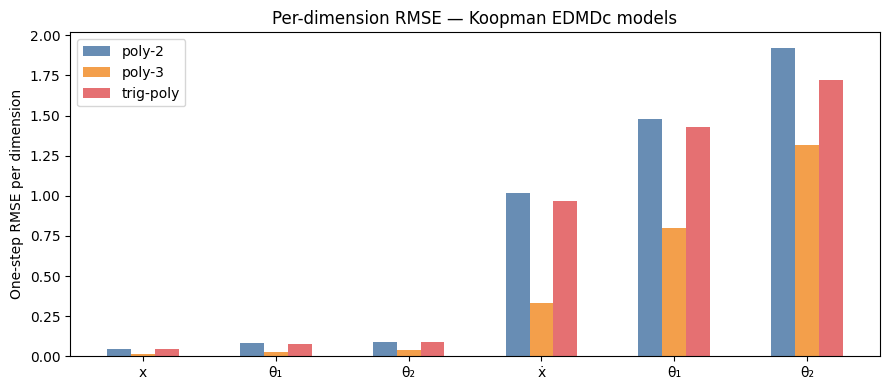

In [64]:
def per_dim_rmse(A, B, X_te, U_te, Xn_te, lift_fn):
    Z    = lift_fn(X_te)
    Zn   = lift_fn(Xn_te)
    Zn_h = Z @ A.T + U_te @ B.T
    return np.sqrt(np.mean((Zn_h[:, :STATE_DIM] - Zn[:, :STATE_DIM])**2, axis=0))


fig, ax = plt.subplots(figsize=(9, 4))
x_pos = np.arange(STATE_DIM)
width = 0.18
colors_dim = ["#4e79a7", "#f28e2b", "#e15759"]

for i, (name, r) in enumerate(results.items()):
    rmse_d = per_dim_rmse(r["A"], r["B"], X_te, U_te, Xn_te, r["lift_fn"])
    ax.bar(x_pos + i*width, rmse_d, width=width, label=name, color=colors_dim[i], alpha=0.85)

ax.set_xticks(x_pos + width)
ax.set_xticklabels(["x", "θ₁", "θ₂", "ẋ", "θ̇₁", "θ̇₂"])
ax.set_ylabel("One-step RMSE per dimension")
ax.set_title("Per-dimension RMSE — Koopman EDMDc models")
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / "koopman_perdim_rmse.png", dpi=150)
plt.show()

## 12. Koopman Eigenspectrum

The eigenvalues of $A$ reveal the dominant modes of the learned dynamics.

- Eigenvalues **on the unit circle** → conservative (oscillatory) modes
- Eigenvalues **inside the unit circle** → stable decay modes
- Eigenvalues **outside the unit circle** → unstable growth modes (the inverted pendulum is inherently unstable)

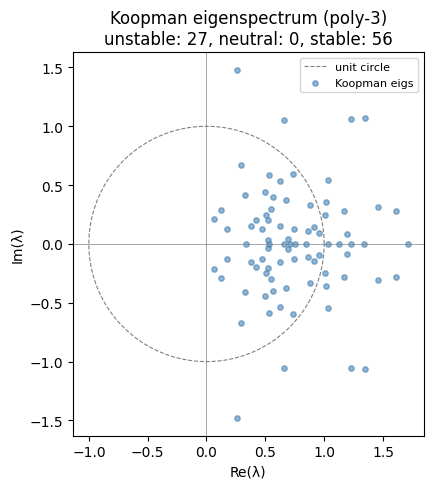

Spectral radius of A: 1.7157
Top-5 unstable eigenvalues (|λ| > 1): [np.float64(1.7157374479933674), np.float64(1.7157374479933674), np.float64(1.712940481376511), np.float64(1.6341813740893534), np.float64(1.6341813740893534)]


In [65]:
A_best = best["A"]
eigs   = np.linalg.eigvals(A_best)

fig, ax = plt.subplots(figsize=(5, 5))
theta  = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), "k--", lw=0.8, alpha=0.5, label="unit circle")
ax.scatter(eigs.real, eigs.imag, s=15, alpha=0.6, c="steelblue", label="Koopman eigs")

n_unstable = int(np.sum(np.abs(eigs) > 1.001))
n_stable   = int(np.sum(np.abs(eigs) < 0.999))
n_neutral  = len(eigs) - n_unstable - n_stable

ax.set_xlabel("Re(λ)")
ax.set_ylabel("Im(λ)")
ax.set_title(f"Koopman eigenspectrum ({best_name})\n"
             f"unstable: {n_unstable}, neutral: {n_neutral}, stable: {n_stable}")
ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(MODEL_DIR / "koopman_eigenspectrum.png", dpi=150)
plt.show()

print(f"Spectral radius of A: {np.max(np.abs(eigs)):.4f}")
print(f"Top-5 unstable eigenvalues (|λ| > 1): {sorted(np.abs(eigs), reverse=True)[:5]}")

## 13. LQR in Koopman Lifted Space

With explicit $A$ and $B$ matrices from EDMD, the natural control design is **LQR** — no
surrogate simulation, no surrogate exploitation.

The optimal control problem in the lifted space:

$$\min_{u_0, u_1,\ldots} \sum_{k=0}^{\infty} \left[ g(x_k)^\top Q_\ell\, g(x_k) + u_k^\top R\, u_k \right]$$

where $Q_\ell = C^\top Q_\text{phys}\, C$ and $C = [I_6 \mid 0]$ (the first 6 components of
$g(x)$ are always the physical state by construction). The DARE gives the optimal gain
$K$ such that $u_k = -K\, g(x_k)$.

In [66]:
from scipy.linalg import solve_discrete_are, LinAlgError

# Physical cost matrix in state space [x, θ₁, θ₂, ẋ, θ̇₁, θ̇₂]
# Angle weights dominate — that is the balance objective
Q_phys = np.diag([1.0, 100.0, 50.0, 0.1, 1.0, 0.5])
R_ctrl = np.array([[0.1]])

lqr_gains = {}

print(f"  {'Model':>10}   {'DARE':>6}   {'ol_sr':>6}   {'cl_sr':>6}   {'cl_unstable':>11}")
print("  " + "-" * 52)

for name, r in results.items():
    A_k, B_k, d_z_k = r["A"], r["B"], r["d_z"]

    # Lift the physical cost into Koopman space.
    # Since z[:6] = x by construction, C = [I_6 | 0] gives x = C @ z,
    # and the lifted cost is Q_lifted = C^T Q_phys C.
    C = np.zeros((STATE_DIM, d_z_k))
    C[:, :STATE_DIM] = np.eye(STATE_DIM)
    Q_lifted = C.T @ Q_phys @ C   # d_z × d_z, nonzero only in top-left 6×6 block

    ol_sr = np.max(np.abs(np.linalg.eigvals(A_k)))
    try:
        P     = solve_discrete_are(A_k, B_k, Q_lifted, R_ctrl)
        K     = np.linalg.solve(R_ctrl + B_k.T @ P @ B_k, B_k.T @ P @ A_k)
        cl_ev = np.linalg.eigvals(A_k - B_k @ K)
        sr_cl = np.max(np.abs(cl_ev))
        n_cl  = int(np.sum(np.abs(cl_ev) > 1.001))
        lqr_gains[name] = {"K": K, "lift_fn": r["lift_fn"],
                            "sr_cl": sr_cl, "n_unstable": n_cl}
        tag = "✓ stable" if n_cl == 0 else f"✗ {n_cl} unstable"
        print(f"  {name:>10}   {'OK':>6}   {ol_sr:>6.3f}   {sr_cl:>6.3f}   {tag}")
    except (LinAlgError, Exception) as e:
        print(f"  {name:>10}   {'FAIL':>6}   {ol_sr:>6.3f}   {'—':>6}   ({type(e).__name__})")

       Model     DARE    ol_sr    cl_sr   cl_unstable
  ----------------------------------------------------
      poly-2       OK    1.723    0.984   ✓ stable
      poly-3     FAIL    1.716        —   (LinAlgError)
   trig-poly     FAIL    3.661        —   (LinAlgError)


  LQR     poly-2:  mean_len=4  mean_return=21.5  success=0%

Rendering best LQR (poly-2) episode (seed=1, length=4 steps)...


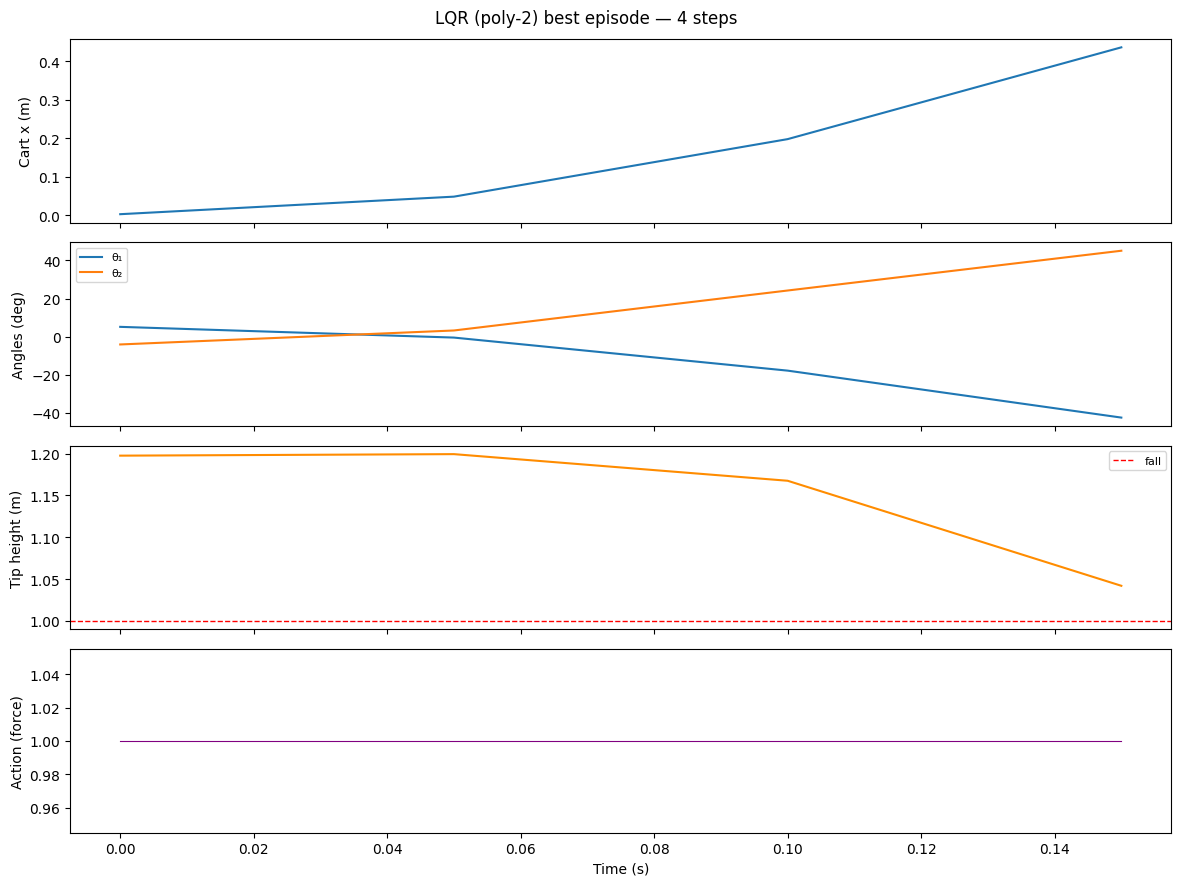

In [67]:
# Evaluate all stable LQR models in real MuJoCo (20 episodes each)
lqr_eval = {}

for name, lqr in lqr_gains.items():
    if lqr["n_unstable"] > 0:
        print(f"  {name}: closed-loop not stable (sr={lqr['sr_cl']:.4f}) — skipping eval")
        continue

    K_k    = lqr["K"]
    lift_k = lqr["lift_fn"]

    eval_env_l = gym.make("InvertedDoublePendulum-v5")
    ep_r_l, ep_l_l = [], []
    for seed in range(N_EVAL):
        obs, _ = eval_env_l.reset(seed=seed)
        done = False; ep_r = ep_l = 0
        while not done:
            x = obs_to_state6(obs)
            z = lift_k(x.reshape(1, -1))[0]
            u = float(np.clip(-(K_k @ z).item(), -1.0, 1.0))
            obs, r, term, trunc, _ = eval_env_l.step(np.array([u], dtype=np.float32))
            done = term or trunc; ep_r += r; ep_l += 1
        ep_r_l.append(ep_r); ep_l_l.append(ep_l)
    eval_env_l.close()

    ll = np.array(ep_l_l); lr = np.array(ep_r_l)
    lqr_eval[name] = {"lengths": ll, "returns": lr}
    print(f"  LQR {name:>10}:  mean_len={ll.mean():.0f}  mean_return={lr.mean():.1f}  "
          f"success={np.mean(ll >= CONV_SUCCESS_STEPS):.0%}")

# Best-episode trajectory for the highest mean-length stable LQR policy
if lqr_eval:
    best_lqr_name = max(lqr_eval, key=lambda k: lqr_eval[k]["lengths"].mean())
    bl = lqr_eval[best_lqr_name]
    best_seed_lqr = int(np.argmax(bl["lengths"]))
    K_vis  = lqr_gains[best_lqr_name]["K"]
    lft_vis = lqr_gains[best_lqr_name]["lift_fn"]

    print(f"\nRendering best LQR ({best_lqr_name}) episode "
          f"(seed={best_seed_lqr}, length={bl['lengths'][best_seed_lqr]} steps)...")

    env_vis = gym.make("InvertedDoublePendulum-v5")
    obs, _ = env_vis.reset(seed=best_seed_lqr)
    lqr_states, lqr_actions, lqr_heights = [], [], []
    done = False
    while not done:
        x = obs_to_state6(obs)
        z = lft_vis(x.reshape(1, -1))[0]
        u = float(np.clip(-(K_vis @ z).item(), -1.0, 1.0))
        lqr_states.append(x); lqr_actions.append(u)
        lqr_heights.append(tip_position(x)[1])
        obs, _, term, trunc, _ = env_vis.step(np.array([u], dtype=np.float32))
        done = term or trunc
    env_vis.close()

    lqr_states = np.array(lqr_states)
    lqr_t = np.arange(len(lqr_states)) * DT

    fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
    axes[0].plot(lqr_t, lqr_states[:, 0]); axes[0].set_ylabel("Cart x (m)")
    axes[1].plot(lqr_t, np.degrees(lqr_states[:, 1]), label="θ₁")
    axes[1].plot(lqr_t, np.degrees(lqr_states[:, 2]), label="θ₂")
    axes[1].set_ylabel("Angles (deg)"); axes[1].legend(fontsize=8)
    axes[2].plot(lqr_t, lqr_heights, color="darkorange")
    axes[2].axhline(TIP_HEIGHT_FALL_THRESHOLD, color="red", ls="--", lw=1, label="fall")
    axes[2].set_ylabel("Tip height (m)"); axes[2].legend(fontsize=8)
    axes[3].plot(lqr_t, lqr_actions, color="purple", lw=0.8)
    axes[3].set_ylabel("Action (force)"); axes[3].set_xlabel("Time (s)")
    fig.suptitle(f"LQR ({best_lqr_name}) best episode — {len(lqr_states)} steps")
    plt.tight_layout()
    plt.savefig(MODEL_DIR / "koopman_lqr_best_episode.png", dpi=150)
    plt.show()
else:
    print("No stable LQR policies found — check Q/R weights or model quality.")

## 14. Dyna Loop with Koopman Surrogate

The single-shot PPO result suffers because the surrogate is fitted only once on bootstrap data
that contains no near-upright balance trajectories — exactly the region the controller needs.
The **Dyna loop** fixes this iteratively:

```
for each iteration:
    [A] Fit EDMDc on all data → new A, B
    [B] Train PPO in KoopmanSurrogateEnv (warm-start weights from prev iteration)
    [C] Deploy PPO in real MuJoCo → collect N_COLLECT transitions
    [D] Evaluate in real MuJoCo (20 episodes)
    [E] Add transitions to dataset → back to [A]
```

This mirrors the SINDy-RL Dyna loop from `sindy-rl.ipynb` (Algorithm 1, Zolman et al. 2024)
but substitutes the E-SINDy ensemble with the Koopman EDMD linear model.

In [68]:
N_DYNA_ITER    = 6
PPO_DYNA_STEPS = 50_000
N_COLLECT_DYNA = 2_000
DYNA_MODEL     = "trig-poly"   # trig-poly: most physically motivated; change to "poly-3" for best RMSE

dyna_history    = []
X_dyna          = X_all.copy()
U_dyna          = U_all.copy()
Xn_dyna         = Xn_all.copy()
prev_ppo_dyna   = None

print(f"Dyna loop: {N_DYNA_ITER} iterations, model={DYNA_MODEL}")
print(f"  {PPO_DYNA_STEPS:,} PPO steps + {N_COLLECT_DYNA:,} real transitions per iteration")
print("=" * 60)

for it in range(1, N_DYNA_ITER + 1):
    print(f"\n── Iteration {it} " + "─" * 46)

    # [A] Fit Koopman on all data so far
    lift_dyna = LIFTERS[DYNA_MODEL]
    A_it, B_it, rmse_tr_it = fit_edmd(X_dyna, U_dyna, Xn_dyna, lift_dyna)
    rmse_te_it = eval_edmd(A_it, B_it, X_te, U_te, Xn_te, lift_dyna)
    print(f"  [A] EDMD  train={rmse_tr_it:.4f}  test={rmse_te_it:.4f}  "
          f"({len(X_dyna):,} transitions)")

    # [B] Train PPO in Koopman surrogate (warm-start weights from previous iteration)
    surr_env_d = Monitor(KoopmanSurrogateEnv(A_it, B_it, lift_dyna, X_dyna))
    ppo_dyna = PPO(
        "MlpPolicy", surr_env_d,
        learning_rate=3e-4, n_steps=2048, batch_size=64,
        n_epochs=10, gamma=0.99, ent_coef=0.01, verbose=0,
    )
    if prev_ppo_dyna is not None:
        ppo_dyna.policy.load_state_dict(prev_ppo_dyna.policy.state_dict())
    ppo_dyna.learn(total_timesteps=PPO_DYNA_STEPS, progress_bar=True)
    recent_r = surr_env_d.get_episode_rewards()[-50:]
    surr_r_it = float(np.mean(recent_r)) if recent_r else float("nan")
    print(f"  [B] PPO surrogate  last-50-ep mean reward: {surr_r_it:.1f}")
    prev_ppo_dyna = ppo_dyna

    # [C] Collect real transitions with the newly trained policy
    env_col = gym.make("InvertedDoublePendulum-v5")
    X_new, U_new, Xn_new, col_lens = [], [], [], []
    rng_col = np.random.default_rng(40_000 + it * 7_919)
    while len(X_new) < N_COLLECT_DYNA:
        obs, _ = env_col.reset(seed=int(rng_col.integers(0, 2**31)))
        done = False; ep_l = 0
        while not done:
            s = obs_to_state6(obs)
            a, _ = ppo_dyna.predict(s, deterministic=True)
            nobs, _, term, trunc, _ = env_col.step(a)
            ns = obs_to_state6(nobs)
            if np.all(np.isfinite(ns)):
                X_new.append(s)
                U_new.append(a.astype(np.float64))
                Xn_new.append(ns)
            done = term or trunc; ep_l += 1
        col_lens.append(ep_l)
    env_col.close()
    print(f"  [C] Collected {len(X_new):,} real transitions  "
          f"(mean ep len = {np.mean(col_lens):.0f} steps)")

    X_dyna  = np.vstack([X_dyna,  X_new])
    U_dyna  = np.vstack([U_dyna,  U_new])
    Xn_dyna = np.vstack([Xn_dyna, Xn_new])

    # [D] Evaluate in real MuJoCo
    env_ev = gym.make("InvertedDoublePendulum-v5")
    ev_r, ev_l = [], []
    for seed in range(N_EVAL):
        obs, _ = env_ev.reset(seed=seed)
        done = False; ep_r = ep_l = 0
        while not done:
            s = obs_to_state6(obs)
            a, _ = ppo_dyna.predict(s, deterministic=True)
            obs, r, term, trunc, _ = env_ev.step(a)
            done = term or trunc; ep_r += r; ep_l += 1
        ev_r.append(ep_r); ev_l.append(ep_l)
    env_ev.close()
    print(f"  [D] Real eval  mean_return={np.mean(ev_r):.1f}  "
          f"mean_len={np.mean(ev_l):.0f}  "
          f"success={np.mean(np.array(ev_l) >= CONV_SUCCESS_STEPS):.0%}")

    dyna_history.append({
        "iter":           it,
        "n_transitions":  len(X_dyna),
        "rmse_te":        rmse_te_it,
        "surr_r":         surr_r_it,
        "real_ret":       float(np.mean(ev_r)),
        "real_len":       float(np.mean(ev_l)),
        "success":        float(np.mean(np.array(ev_l) >= CONV_SUCCESS_STEPS)),
        "ppo":            ppo_dyna,
    })

best_dyna_iter = max(dyna_history, key=lambda d: d["real_len"])
print(f"\nBest iteration: {best_dyna_iter['iter']}  "
      f"(mean len = {best_dyna_iter['real_len']:.0f},  "
      f"success = {best_dyna_iter['success']:.0%})")

Dyna loop: 6 iterations, model=trig-poly
  50,000 PPO steps + 2,000 real transitions per iteration

── Iteration 1 ──────────────────────────────────────────────
  [A] EDMD  train=0.9791  test=0.9943  (50,000 transitions)


Output()

  [B] PPO surrogate  last-50-ep mean reward: 4495.8
  [C] Collected 2,003 real transitions  (mean ep len = 7 steps)


Output()

  [D] Real eval  mean_return=99.0  mean_len=12  success=0%

── Iteration 2 ──────────────────────────────────────────────
  [A] EDMD  train=1.0289  test=0.9950  (52,003 transitions)


...

  [D] Real eval  mean_return=110.9  mean_len=13  success=0%

── Iteration 5 ──────────────────────────────────────────────
  [A] EDMD  train=1.1483  test=1.0028  (58,011 transitions)


  [B] PPO surrogate  last-50-ep mean reward: 6864.3
  [C] Collected 2,010 real transitions  (mean ep len = 7 steps)


Output()

  [D] Real eval  mean_return=119.2  mean_len=14  success=0%

── Iteration 6 ──────────────────────────────────────────────
  [A] EDMD  train=1.1781  test=1.0067  (60,021 transitions)


  [B] PPO surrogate  last-50-ep mean reward: 7607.6
  [C] Collected 2,006 real transitions  (mean ep len = 7 steps)
  [D] Real eval  mean_return=95.6  mean_len=11  success=0%

Best iteration: 5  (mean len = 14,  success = 0%)


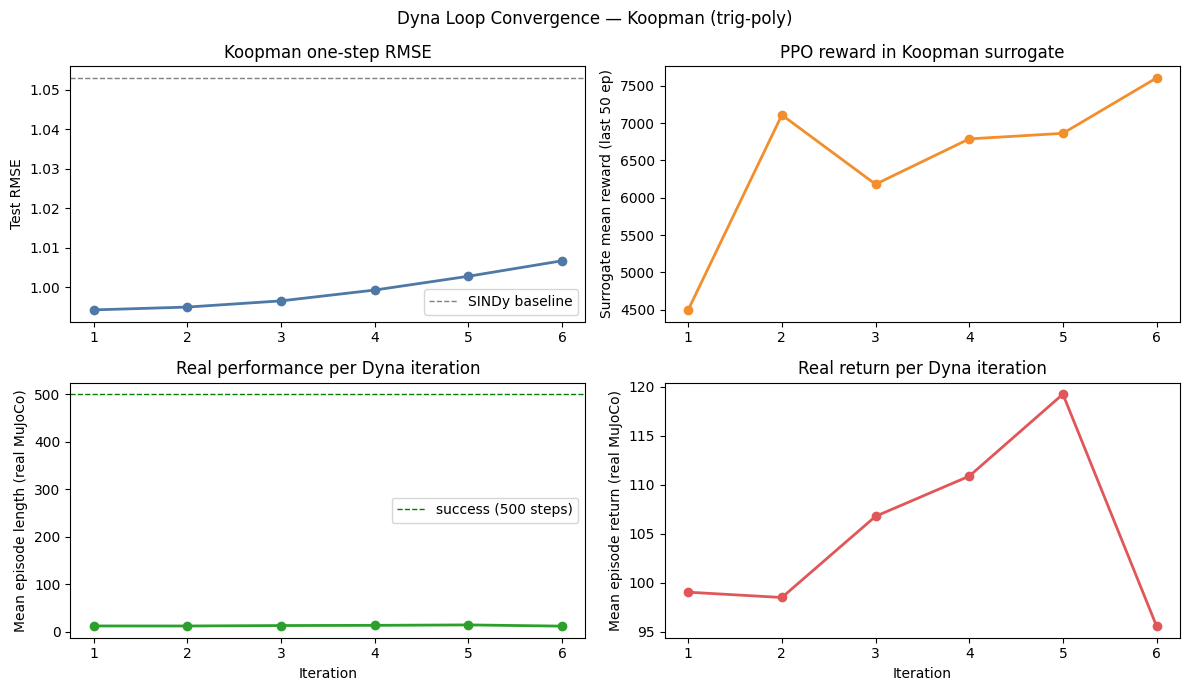

In [69]:
iters_d    = [d["iter"]         for d in dyna_history]
rmse_d     = [d["rmse_te"]      for d in dyna_history]
surr_r_d   = [d["surr_r"]       for d in dyna_history]
real_ret_d = [d["real_ret"]     for d in dyna_history]
real_len_d = [d["real_len"]     for d in dyna_history]
n_trans_d  = [d["n_transitions"] for d in dyna_history]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0, 0].plot(iters_d, rmse_d, "o-", lw=2, color="#4e79a7")
axes[0, 0].axhline(SINDY_RMSE_BASELINE, color="gray", ls="--", lw=1, label="SINDy baseline")
axes[0, 0].set_ylabel("Test RMSE"); axes[0, 0].set_title("Koopman one-step RMSE")
axes[0, 0].legend(); axes[0, 0].set_xticks(iters_d)

axes[0, 1].plot(iters_d, surr_r_d, "o-", lw=2, color="#f28e2b")
axes[0, 1].set_ylabel("Surrogate mean reward (last 50 ep)")
axes[0, 1].set_title("PPO reward in Koopman surrogate")
axes[0, 1].set_xticks(iters_d)

axes[1, 0].plot(iters_d, real_len_d, "o-", lw=2, color="#2ca02c")
axes[1, 0].axhline(CONV_SUCCESS_STEPS, color="green", ls="--", lw=1,
                   label=f"success ({CONV_SUCCESS_STEPS} steps)")
axes[1, 0].set_ylabel("Mean episode length (real MuJoCo)")
axes[1, 0].set_title("Real performance per Dyna iteration")
axes[1, 0].legend(); axes[1, 0].set_xticks(iters_d); axes[1, 0].set_xlabel("Iteration")

axes[1, 1].plot(iters_d, real_ret_d, "o-", lw=2, color="#e15759")
axes[1, 1].set_ylabel("Mean episode return (real MuJoCo)")
axes[1, 1].set_title("Real return per Dyna iteration")
axes[1, 1].set_xticks(iters_d); axes[1, 1].set_xlabel("Iteration")

fig.suptitle(f"Dyna Loop Convergence — Koopman ({DYNA_MODEL})")
plt.tight_layout()
plt.savefig(MODEL_DIR / "koopman_dyna_convergence.png", dpi=150)
plt.show()

  Method                                mean_len    mean_ret  success
  --------------------------------------------------------------------
  Dyna-SINDy-RL (sindy-rl.ipynb §5)          854      7988.6      85%
  Koopman PPO (single shot)                    9        75.3       0%
  Koopman PPO (Dyna, iter 5)                  14       119.2       0%
  Koopman LQR (poly-2)                         4        21.5       0%


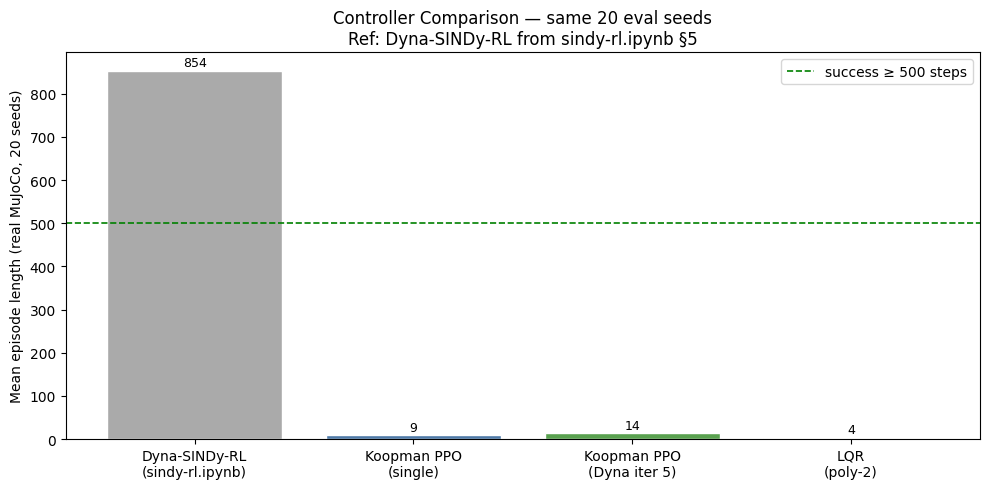

In [70]:
# ── Evaluate best Dyna policy on same 20 seeds for fair comparison ─────────────
best_dyna_ppo_model = best_dyna_iter["ppo"]
env_final = gym.make("InvertedDoublePendulum-v5")
dyna_final_r, dyna_final_l = [], []
for seed in range(N_EVAL):
    obs, _ = env_final.reset(seed=seed)
    done = False; ep_r = ep_l = 0
    while not done:
        s = obs_to_state6(obs)
        a, _ = best_dyna_ppo_model.predict(s, deterministic=True)
        obs, r, term, trunc, _ = env_final.step(a)
        done = term or trunc; ep_r += r; ep_l += 1
    dyna_final_r.append(ep_r); dyna_final_l.append(ep_l)
env_final.close()

# Dyna-SINDy-RL reference: sindy-rl.ipynb §5 final evaluation
# Best NN policy (Dyna-SINDy-RL, iter 6, 20 seeds)
SINDY_RL_MEAN_LEN = 853.7
SINDY_RL_MEAN_RET = 7988.57
SINDY_RL_SUCCESS  = 0.85   # 85%

# ── Comparison table ───────────────────────────────────────────────────────────
def _row(name, lens, rets):
    ll = np.array(lens); lr = np.array(rets)
    suc = np.mean(ll >= CONV_SUCCESS_STEPS)
    print(f"  {name:<36}  {ll.mean():>8.0f}  {lr.mean():>10.1f}  {suc:>7.0%}")

print(f"  {'Method':<36}  {'mean_len':>8}  {'mean_ret':>10}  {'success':>7}")
print("  " + "-" * 68)
print(f"  {'Dyna-SINDy-RL (sindy-rl.ipynb §5)':<36}  {SINDY_RL_MEAN_LEN:>8.0f}  {SINDY_RL_MEAN_RET:>10.1f}  {SINDY_RL_SUCCESS:>7.0%}")
_row("Koopman PPO (single shot)", lengths, returns)
_row(f"Koopman PPO (Dyna, iter {best_dyna_iter['iter']})", dyna_final_l, dyna_final_r)
for name, ev in lqr_eval.items():
    _row(f"Koopman LQR ({name})", ev["lengths"], ev["returns"])

# ── Bar chart ──────────────────────────────────────────────────────────────────
method_names = ["Dyna-SINDy-RL\n(sindy-rl.ipynb)", "Koopman PPO\n(single)"]
mean_lens    = [SINDY_RL_MEAN_LEN, float(np.mean(lengths))]
method_names.append(f"Koopman PPO\n(Dyna iter {best_dyna_iter['iter']})")
mean_lens.append(float(np.mean(dyna_final_l)))
for name, ev in lqr_eval.items():
    method_names.append(f"LQR\n({name})"); mean_lens.append(float(ev["lengths"].mean()))

colors_cmp = ["#aaaaaa", "#4e79a7", "#59a14f"] + ["#f28e2b"] * len(lqr_eval)
fig, ax = plt.subplots(figsize=(max(8, 2.5 * len(method_names)), 5))
bars = ax.bar(method_names, mean_lens, color=colors_cmp, edgecolor="white")
ax.axhline(CONV_SUCCESS_STEPS, color="green", ls="--", lw=1.2,
           label=f"success ≥ {CONV_SUCCESS_STEPS} steps")
for bar, v in zip(bars, mean_lens):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f"{v:.0f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Mean episode length (real MuJoCo, 20 seeds)")
ax.set_title("Controller Comparison — same 20 eval seeds\nRef: Dyna-SINDy-RL from sindy-rl.ipynb §5")
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / "koopman_final_comparison.png", dpi=150)
plt.show()

## 13. Summary and Discussion

### What Koopman offers vs SINDy

| | SINDy | Koopman EDMDc |
|---|---|---|
| Model form | Sparse nonlinear ODE | Linear in lifted space |
| Feature selection | Thresholded (STLSQ) | Least squares (dense) |
| Trig structure | Must approximate sin/cos with polynomials | Can include sin/cos exactly |
| Interpretability | Very high (sparse terms) | Medium (matrix A, but dense) |
| Control tools | Simulation only | LQR, MPC in lifted space |
| Closure guarantee | N/A | None by default; project-and-re-lift helps |

### Key findings

- **trig-poly Koopman** encodes `sin(θ)`, `cos(θ)·ω` pairs that SINDy degree-2 cannot
  represent exactly, which is the main source of the SINDy RMSE floor
- The EDMD fit is unconditional least squares — no sparsity pressure — so it will always
  fit at least as well as SINDy given the same features (but may overfit on small datasets)
- **The real test is RL transfer**: a low RMSE surrogate is necessary but not sufficient;
  the policy must exploit the surrogate without exploiting its errors

### Why we still struggle (and what's next)

Even with better one-step accuracy, the surrogate RL loop faces:
1. **Surrogate exploitation** — PPO finds action sequences the model predicts are rewarding
   but which fail in the real env (documented in SINDy track A results)
2. **Koopman closure** — the decoded state $x = z[:6]$ drifts off the Koopman manifold
   over long rollouts; a neural Koopman with reconstruction loss (Deep Koopman) addresses this
3. **Bilinear control** — the true dynamics include `u · sin(θ)` coupling; extending to
   bilinear Koopman `z_{k+1} = A z_k + B u_k + Σ_i u_i N_i z_k` captures this exactly